# Form 4 factor model — mentor revision

Main changes:
1. Use **abnormal forward return** instead of raw forward return so stocks are not compared only on market movement.
2. Normalize the target by each ticker's historical abnormal-return volatility.
3. Add Form 4 activity features and use ticker-balanced sample weights so high-activity stocks do not dominate the model.
4. Replace `GradientBoostingRegressor` with `HistGradientBoostingRegressor`.
5. Use event-date portfolio weights normalized by daily absolute exposure for a cleaner event backtest.

In [107]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

from form4_cache_manager import (
    DATA_DIR,
    load_or_update_form4_for_tickers,
    load_or_update_form4_for_ticker,
)
from price_cache_manager import get_clean_price_df

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [108]:
spx = get_clean_price_df(["SPY"]).copy()

Processing SPY...


In [ ]:
# Keep Form 4 tickers and price tickers consistent.
tickers = [
    "AAPL", "META", "GOOGL", "AMZN",
    "MSFT", "NVDA", "AMD", "TSLA",
]

filings_all, common_all, options_all = load_or_update_form4_for_tickers(
    tickers,
    n_if_no_cache=None,   # use a smaller number such as 50 for the first test run if EDGAR is slow
    data_dir=DATA_DIR,
)

price = get_clean_price_df(tickers).copy()

print("Common Form 4 rows:", common_all.shape)
print("Price rows:", price.shape)


Loading/updating Form 4 data for AAPL...
Cache found for AAPL. Checking for updates...
AAPL: cache is already up to date.
Finished AAPL. Sleeping 6.2s before next ticker...


In [110]:
# def _standardize_bool(s):
#     """Convert common True/False/string/1/0 values to 0/1."""
#     return (
#         s.astype(str)
#         .str.strip()
#         .str.lower()
#         .map({"true": 1, "false": 0, "1": 1, "0": 0, "yes": 1, "no": 0})
#         .fillna(0)
#         .astype(int)
#     )


def _prep_price(price_df, benchmark_df=None, horizon=20):
    """Prepare stock price data and compute forward raw/SPY-abnormal returns."""
    price = price_df.copy()

    if "date" in price.columns and "trade_date" not in price.columns:
        price = price.rename(columns={"date": "trade_date"})

    price["trade_date"] = pd.to_datetime(price["trade_date"])
    price["close"] = pd.to_numeric(price["close"], errors="coerce")
    price = price.dropna(subset=["ticker", "trade_date", "close"])
    price = price.sort_values(["ticker", "trade_date"]).reset_index(drop=True)

    # Historical moving averages.
    # shift(1) avoids using the current trade_date close inside the moving average.
    price["close_ma20"] = (
        price.groupby("ticker")["close"]
        .transform(lambda s: s.shift(1).rolling(20, min_periods=5).mean())
    )

    price["close_ma60"] = (
        price.groupby("ticker")["close"]
        .transform(lambda s: s.shift(1).rolling(60, min_periods=10).mean())
    )

    # Stock forward return
    price["future_price"] = price.groupby("ticker")["close"].shift(-horizon)
    price["future_return"] = price["future_price"] / price["close"] - 1

    # =========================
    # Benchmark return: SPY / SPX
    # =========================
    if benchmark_df is not None:
        bench = benchmark_df.copy()

        if "date" in bench.columns and "trade_date" not in bench.columns:
            bench = bench.rename(columns={"date": "trade_date"})

        bench["trade_date"] = pd.to_datetime(bench["trade_date"])
        bench["close"] = pd.to_numeric(bench["close"], errors="coerce")
        bench = bench.dropna(subset=["trade_date", "close"])
        bench = bench.sort_values("trade_date").reset_index(drop=True)

        # If benchmark_df contains only SPY, this is fine.
        # If it contains multiple tickers, keep the first ticker.
        if "ticker" in bench.columns and not bench.empty:
            bench_ticker = bench["ticker"].iloc[0]
            bench = bench[bench["ticker"] == bench_ticker].copy()

        bench["benchmark_future_price"] = bench["close"].shift(-horizon)
        bench["benchmark_return"] = bench["benchmark_future_price"] / bench["close"] - 1

        bench = bench[["trade_date", "benchmark_return"]].dropna()

        price = price.merge(
            bench,
            on="trade_date",
            how="left"
        )

    else:
        # Fallback: cross-sectional benchmark if no SPY/SPX is provided.
        price["benchmark_return"] = price.groupby("trade_date")["future_return"].transform("mean")

    price["y_abnormal"] = price["future_return"] - price["benchmark_return"]

    return price


def _add_activity_features(events):
    """Add leakage-safe historical Form 4 activity features by ticker."""
    out = events.copy().sort_values(["ticker", "event_date"]).reset_index(drop=True)

    pieces = []
    for ticker, g in out.groupby("ticker", sort=False):
        g = g.sort_values("event_date").copy()
        dates = g["event_date"].to_numpy(dtype="datetime64[ns]")
        idx = np.arange(len(g))

        for days in [20, 60, 252]:
            left = np.searchsorted(dates, dates - np.timedelta64(days, "D"), side="left")
            # count past events only; current event is excluded to avoid leakage
            g[f"event_count_{days}d"] = idx - left
            g[f"log_event_count_{days}d"] = np.log1p(g[f"event_count_{days}d"])

        g["days_since_prev_event"] = g["event_date"].diff().dt.days
        pieces.append(g)

    out = pd.concat(pieces, ignore_index=True)
    return out.sort_values(["event_date", "ticker"]).reset_index(drop=True)


def build_event_dataset(
    form4_df,
    price_df,
    benchmark_df=None,
    horizon=20,
    min_periods_norm=20,
    execution_lag_days=1,
):
    """
    Build event-level target data.

    Target logic:
    raw_y          = stock forward return over `horizon` trading days
    benchmark      = SPY/SPX forward return over the same horizon
    y_abnormal     = raw_y - benchmark_return

    To avoid leakage:
    pricing_date   = event_date + execution_lag_days
    trade_date     = next available trading day on/after pricing_date
    price_t        = close price on trade_date
    future_price   = close price horizon trading days after trade_date
    """
    df = form4_df.copy()
    price = _prep_price(price_df, benchmark_df=benchmark_df, horizon=horizon)

    # Original Form 4 transaction date
    df["event_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")
    df = df.dropna(subset=["ticker", "event_date"])
    df = df.sort_values(["ticker", "event_date"]).reset_index(drop=True)

    # Push execution/pricing date forward to avoid leakage
    df["pricing_date"] = df["event_date"] + pd.Timedelta(days=execution_lag_days)

    # Optional: keep price only around event window
    min_pricing_date = df["pricing_date"].min()
    max_pricing_date = df["pricing_date"].max()

    price = price[
        (price["trade_date"] >= min_pricing_date - pd.Timedelta(days=5)) &
        (price["trade_date"] <= max_pricing_date + pd.Timedelta(days=90))
    ].copy()

    price_cols = [
        "ticker",
        "trade_date",
        "close",
        "future_price",
        "future_return",
        "benchmark_return",
        "y_abnormal",
    ]

    # Use the next available trading day after pricing_date
    merged = []

    for ticker, g in df.groupby("ticker", sort=False):
        p = price.loc[
            price["ticker"] == ticker,
            price_cols
        ].sort_values("trade_date")

        if p.empty:
            continue

        m = pd.merge_asof(
            g.sort_values("pricing_date"),
            p,
            left_on="pricing_date",
            right_on="trade_date",
            by="ticker",
            direction="forward",
            allow_exact_matches=True,
        )

        merged.append(m)

    if not merged:
        raise ValueError(
            "No Form 4 events could be matched to price data. Check ticker/date coverage."
        )

    out = pd.concat(merged, ignore_index=True)

    out = out.rename(columns={
        "close": "price_t",
        "future_return": "raw_y",
    })

    # Drop rows without valid forward return / benchmark
    out = out.dropna(subset=["price_t", "future_price", "raw_y", "benchmark_return", "y_abnormal"])

    # Clean target
    out = out.sort_values(["ticker", "event_date"]).reset_index(drop=True)

    grp = out.groupby("ticker")["y_abnormal"]

    hist_mean = grp.transform(
        lambda s: s.expanding(min_periods=min_periods_norm).mean().shift(1)
    )
    hist_std = grp.transform(
        lambda s: s.expanding(min_periods=min_periods_norm).std().shift(1)
    )

    out["y_norm"] = (out["y_abnormal"] - hist_mean) / (hist_std + 1e-8)

    # Keep y clean and interpretable
    out["y"] = out["y_abnormal"]

    out = _add_activity_features(out)

    return out

In [111]:
def build_features(df):
    """Feature engineering for Form 4 gradient boosting models."""
    X = df.copy()

    # =========================
    # Numeric Form 4 fields
    # =========================
    for col in ["shares", "price_per_share", "shares_owned_following"]:
        if col not in X.columns:
            X[col] = np.nan
        X[col] = pd.to_numeric(X[col], errors="coerce")

    # =========================
    # Basic transaction direction
    # A = acquired, D = disposed
    # =========================
    adc = (
        X.get("acquired_disposed_code", pd.Series(index=X.index, dtype=object))
        .astype(str)
        .str.strip()
        .str.upper()
    )

    X["is_buy"] = (adc == "A").astype(int)
    X["is_sell"] = (adc == "D").astype(int)
    X["signed_direction"] = X["is_buy"] - X["is_sell"]

    # =========================
    # Insider role flags
    # =========================
    for col in ["is_director", "is_officer", "is_ten_percent_owner"]:
        if col not in X.columns:
            X[col] = 0
        X[col] = pd.to_numeric(X[col], errors="coerce").fillna(0).astype(int)

    X["insider_role_count"] = X[
        ["is_director", "is_officer", "is_ten_percent_owner"]
    ].sum(axis=1)

    X["insider_importance"] = 1 + X["insider_role_count"]

    # =========================
    # Transaction magnitude features
    # =========================
    X["abs_shares"] = X["shares"].abs()
    X["signed_shares"] = X["signed_direction"] * X["abs_shares"]

    # transaction_price is the reported Form 4 price_per_share.
    # It can be NaN for option exercise / grant rows.
    X["transaction_price"] = pd.to_numeric(X["price_per_share"], errors="coerce")

    # Use price_t only as a fallback for dollar-value calculation.
    # Do NOT use this raw price directly as a model feature.
    if "price_t" in X.columns:
        X["effective_price_for_value"] = X["transaction_price"].fillna(X["price_t"])
    else:
        X["effective_price_for_value"] = X["transaction_price"]

    X["effective_price_for_value"] = pd.to_numeric(
        X["effective_price_for_value"],
        errors="coerce"
    )

    X["dollar_value"] = X["abs_shares"] * X["effective_price_for_value"].abs()
    X["signed_dollar_value"] = X["signed_direction"] * X["dollar_value"]
    X["weighted_signed_dollar_value"] = (
        X["signed_dollar_value"] * X["insider_importance"]
    )

    # =========================
    # Relative transaction price features
    # These replace raw effective_price as model features.
    # =========================
    if "price_t" in X.columns:
        X["tx_price_gt_close"] = (X["transaction_price"] > X["price_t"]).astype(float)
        X["tx_price_lt_close"] = (X["transaction_price"] < X["price_t"]).astype(float)
        X["tx_price_vs_close"] = X["transaction_price"] / X["price_t"] - 1
    else:
        X["tx_price_gt_close"] = np.nan
        X["tx_price_lt_close"] = np.nan
        X["tx_price_vs_close"] = np.nan

    if "close_ma20" in X.columns:
        X["tx_price_gt_ma20"] = (X["transaction_price"] > X["close_ma20"]).astype(float)
        X["tx_price_lt_ma20"] = (X["transaction_price"] < X["close_ma20"]).astype(float)
        X["tx_price_vs_ma20"] = X["transaction_price"] / X["close_ma20"] - 1
    else:
        X["tx_price_gt_ma20"] = np.nan
        X["tx_price_lt_ma20"] = np.nan
        X["tx_price_vs_ma20"] = np.nan

    if "close_ma60" in X.columns:
        X["tx_price_gt_ma60"] = (X["transaction_price"] > X["close_ma60"]).astype(float)
        X["tx_price_lt_ma60"] = (X["transaction_price"] < X["close_ma60"]).astype(float)
        X["tx_price_vs_ma60"] = X["transaction_price"] / X["close_ma60"] - 1
    else:
        X["tx_price_gt_ma60"] = np.nan
        X["tx_price_lt_ma60"] = np.nan
        X["tx_price_vs_ma60"] = np.nan

    # Net-flow row-level features.
    # After ticker-date aggregation, these become true net buy / net sell measures.
    X["net_shares"] = X["signed_shares"]
    X["net_dollar_value"] = X["signed_dollar_value"]

    X["log_abs_shares"] = np.log1p(X["abs_shares"])
    X["log_dollar_value"] = np.log1p(X["dollar_value"])
    X["signed_log_dollar_value"] = X["signed_direction"] * X["log_dollar_value"]

    X["ownership_after_log"] = np.log1p(
        X["shares_owned_following"].clip(lower=0)
    )

    X["relative_trade_size"] = (
        X["abs_shares"] / (X["shares_owned_following"].abs() + 1.0)
    )

    # =========================
    # Filing delay
    # =========================
    if "filing_date" in X.columns:
        X["filing_date"] = pd.to_datetime(X["filing_date"], errors="coerce")
        X["filing_delay_days"] = (
            X["filing_date"] - X["event_date"]
        ).dt.days.clip(lower=0)
    else:
        X["filing_delay_days"] = np.nan

    # =========================
    # Transaction code indicators
    # P = open-market purchase
    # S = sale
    # A = grant
    # M = option exercise
    # F = tax withholding
    # =========================
    code = (
        X.get("transaction_code", pd.Series(index=X.index, dtype=object))
        .astype(str)
        .str.strip()
        .str.upper()
    )

    for c in ["P", "S", "A", "M", "F"]:
        X[f"tx_code_{c}"] = (code == c).astype(int)

    # =========================
    # Interactions
    # =========================
    X["officer_buy"] = X["is_officer"] * X["is_buy"]
    X["officer_sell"] = X["is_officer"] * X["is_sell"]
    X["director_buy"] = X["is_director"] * X["is_buy"]
    X["tenpct_buy"] = X["is_ten_percent_owner"] * X["is_buy"]

    # =========================
    # Net buy / sell decomposition
    # These are especially useful after ticker-date aggregation.
    # =========================
    X["net_buy_shares"] = X["net_shares"].clip(lower=0)
    X["net_sell_shares"] = (-X["net_shares"]).clip(lower=0)

    X["net_buy_dollar"] = X["net_dollar_value"].clip(lower=0)
    X["net_sell_dollar"] = (-X["net_dollar_value"]).clip(lower=0)

    X["net_shares_sign"] = np.sign(X["net_shares"]).fillna(0)
    X["net_dollar_sign"] = np.sign(X["net_dollar_value"]).fillna(0)

    X["log_abs_net_shares"] = np.log1p(X["net_shares"].abs())
    X["log_abs_net_dollar"] = np.log1p(X["net_dollar_value"].abs())

    X["net_dollar_to_trade_dollar"] = (
        X["net_dollar_value"] / (X["dollar_value"].abs() + 1.0)
    )

    # =========================
    # Activity normalization features
    # These are created/recomputed outside build_features().
    # =========================
    activity_cols = [
        "event_count_20d",
        "event_count_60d",
        "event_count_252d",
        "log_event_count_20d",
        "log_event_count_60d",
        "log_event_count_252d",
        "days_since_prev_event",
    ]

    for col in activity_cols:
        if col not in X.columns:
            X[col] = np.nan

    # =========================
    # Missingness flags
    # =========================
    X["missing_price_per_share"] = X["price_per_share"].isna().astype(int)
    X["missing_shares_owned_following"] = (
        X["shares_owned_following"].isna().astype(int)
    )

    feature_cols = [
        "is_buy",
        "is_sell",
        "signed_direction",

        "is_director",
        "is_officer",
        "is_ten_percent_owner",
        "insider_role_count",
        "insider_importance",

        "tx_price_gt_close",
        "tx_price_lt_close",
        "tx_price_vs_close",

        "tx_price_gt_ma20",
        "tx_price_lt_ma20",
        "tx_price_vs_ma20",

        "tx_price_gt_ma60",
        "tx_price_lt_ma60",
        "tx_price_vs_ma60",

        "log_abs_shares",
        "log_dollar_value",
        "signed_log_dollar_value",

        "signed_shares",
        "signed_dollar_value",
        "weighted_signed_dollar_value",

        "net_shares",
        "net_dollar_value",
        "net_buy_shares",
        "net_sell_shares",
        "net_buy_dollar",
        "net_sell_dollar",
        "net_shares_sign",
        "net_dollar_sign",
        "log_abs_net_shares",
        "log_abs_net_dollar",
        "net_dollar_to_trade_dollar",

        "ownership_after_log",
        "relative_trade_size",
        "filing_delay_days",

        "tx_code_P",
        "tx_code_S",
        "tx_code_A",
        "tx_code_M",
        "tx_code_F",

        "officer_buy",
        "officer_sell",
        "director_buy",
        "tenpct_buy",

        *activity_cols,

        "missing_price_per_share",
        "missing_shares_owned_following",
    ]

    df_out = df.copy()
    df_out[feature_cols] = X[feature_cols]

    return df_out, feature_cols

In [121]:
def aggregate_features_by_ticker_date(df, feature_cols):
    """
    Aggregate row-level Form 4 features into one ticker-date observation.

    This avoids duplicated targets for the same ticker-date and converts
    multiple Form 4 rows on the same date into net insider-flow features.
    """
    out = df.copy()

    # =========================
    # Base target / price columns
    # These should be identical for rows with the same ticker-date.
    # =========================
    base_cols = [
        "ticker",
        "event_date",
        "pricing_date",
        "trade_date",
        "price_t",
        "close_ma20",
        "close_ma60",
        "future_price",
        "raw_y",
        "benchmark_return",
        "y_abnormal",
        "y",
        "y_norm",
    ]

    agg = {}

    for col in base_cols:
        if col in out.columns:
            agg[col] = "first"

    # =========================
    # Flags: use max
    # If any row on the ticker-date has this flag, the aggregated row has it.
    # =========================
    max_cols = [
        "is_buy",
        "is_sell",
        "is_director",
        "is_officer",
        "is_ten_percent_owner",

        "tx_code_P",
        "tx_code_S",
        "tx_code_A",
        "tx_code_M",
        "tx_code_F",

        "officer_buy",
        "officer_sell",
        "director_buy",
        "tenpct_buy",

        "missing_price_per_share",
        "missing_shares_owned_following",
    ]

    # =========================
    # Signed / net quantities: use sum
    # Multiple rows on the same day should combine into one net flow.
    # =========================
    sum_cols = [
        "signed_direction",
        "signed_shares",
        "signed_dollar_value",
        "weighted_signed_dollar_value",

        "net_shares",
        "net_dollar_value",

        "net_buy_shares",
        "net_sell_shares",
        "net_buy_dollar",
        "net_sell_dollar",
    ]

    # =========================
    # Positive magnitudes: use sum
    # These represent total amount of Form 4 activity that day.
    # =========================
    sum_positive_cols = [
        "abs_shares",
        "dollar_value",
    ]

    # =========================
    # Continuous row-level quantities: use mean
    # =========================
    mean_cols = [
        "shares",
        "price_per_share",
        "transaction_price",
        # "effective_price_for_value",
        "shares_owned_following",

        "insider_role_count",
        "insider_importance",

        "log_abs_shares",
        "log_dollar_value",
        "signed_log_dollar_value",

        "tx_price_gt_close",
        "tx_price_lt_close",
        "tx_price_vs_close",

        "tx_price_gt_ma20",
        "tx_price_lt_ma20",
        "tx_price_vs_ma20",

        "tx_price_gt_ma60",
        "tx_price_lt_ma60",
        "tx_price_vs_ma60",

        "ownership_after_log",
        "relative_trade_size",
        "filing_delay_days",
    ]

    # =========================
    # Activity features should be recomputed after aggregation.
    # Do not preserve old row-level activity values.
    # =========================
    activity_cols = [
        "event_count_20d",
        "event_count_60d",
        "event_count_252d",
        "log_event_count_20d",
        "log_event_count_60d",
        "log_event_count_252d",
        "days_since_prev_event",
    ]

    for col in max_cols:
        if col in out.columns:
            agg[col] = "max"

    for col in sum_cols + sum_positive_cols:
        if col in out.columns:
            agg[col] = "sum"

    for col in mean_cols:
        if col in out.columns:
            agg[col] = "mean"

    # For any remaining feature columns not listed above, use mean as fallback.
    # Skip activity columns because they will be recomputed later.
    for col in feature_cols:
        if (
            col in out.columns
            and col not in agg
            and col not in ["ticker", "event_date"]
            and col not in activity_cols
        ):
            agg[col] = "mean"

    out = (
        out.sort_values(["ticker", "event_date"])
        .groupby(["ticker", "event_date"], as_index=False)
        .agg(agg)
    )

    # =========================
    # Recompute true post-aggregation net-flow features
    # =========================
    if "net_shares" in out.columns:
        out["net_buy_shares"] = out["net_shares"].clip(lower=0)
        out["net_sell_shares"] = (-out["net_shares"]).clip(lower=0)
        out["net_shares_sign"] = np.sign(out["net_shares"]).fillna(0)
        out["log_abs_net_shares"] = np.log1p(out["net_shares"].abs())

    if "net_dollar_value" in out.columns:
        out["net_buy_dollar"] = out["net_dollar_value"].clip(lower=0)
        out["net_sell_dollar"] = (-out["net_dollar_value"]).clip(lower=0)
        out["net_dollar_sign"] = np.sign(out["net_dollar_value"]).fillna(0)
        out["log_abs_net_dollar"] = np.log1p(out["net_dollar_value"].abs())

    if "net_dollar_value" in out.columns and "dollar_value" in out.columns:
        out["net_dollar_to_trade_dollar"] = (
            out["net_dollar_value"] / (out["dollar_value"].abs() + 1.0)
        )

    return out

In [137]:
def train_model(df, feature_cols, target_col="y", test_size=0.2):
    """
    Train HistGradientBoostingRegressor with time split and ticker-balanced weights.

    Ticker-balanced weights prevent high Form 4 activity stocks from dominating the loss.
    """
    data = df.copy()
    data = data.dropna(subset=[target_col, "event_date", "ticker"])
    data = data.sort_values("event_date").reset_index(drop=True)

    # Winsorize the target to reduce the influence of extreme event returns.
    q_low, q_high = data[target_col].quantile([0.01, 0.99])
    data[target_col] = data[target_col].clip(q_low, q_high)

    X = data[feature_cols].replace([np.inf, -np.inf], np.nan)
    y = data[target_col].astype(float)

    split = int(len(data) * (1 - test_size))
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]
    train_meta, test_meta = data.iloc[:split].copy(), data.iloc[split:].copy()

    # Equalize total training weight across tickers.
    ticker_counts = train_meta["ticker"].value_counts()
    sample_weight = 1.0 / train_meta["ticker"].map(ticker_counts).astype(float)
    sample_weight = sample_weight / sample_weight.mean()

    model = HistGradientBoostingRegressor(
        loss="squared_error",
        max_iter=120,
        learning_rate=0.03,
        max_leaf_nodes=6,
        min_samples_leaf=80,
        l2_regularization=5.0,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=15,
        random_state=42,
    )

    model.fit(X_train, y_train, sample_weight=sample_weight)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    metrics = {
        "n_train": len(X_train),
        "n_test": len(X_test),
        "target": target_col,
        "train_r2": r2_score(y_train, pred_train),
        "test_r2": r2_score(y_test, pred_test),
        "train_mae": mean_absolute_error(y_train, pred_train),
        "test_mae": mean_absolute_error(y_test, pred_test),
        "best_iteration": getattr(model, "n_iter_", None),
    }

    print("Model metrics")
    for k, v in metrics.items():
        print(f"{k}: {v}")

    return model, metrics, (X_train, X_test, y_train, y_test, train_meta, test_meta)

In [138]:
def generate_positions(df, model, feature_cols, min_events_per_day=2):
    """
    Convert predictions into event-date long/short weights.

    Daily absolute exposure is normalized to 1, so days with many Form 4 rows do not
    mechanically receive larger portfolio exposure than sparse days.
    """
    out = df.copy()
    X_pred = out[feature_cols].replace([np.inf, -np.inf], np.nan)
    out["pred"] = model.predict(X_pred)

    def _daily_weights(g):
        g = g.copy()
        if len(g) < min_events_per_day:
            g["position"] = 0.0
            return g

        # Rank signal is robust to noisy prediction scale.
        g["rank"] = g["pred"].rank(pct=True)
        signal = g["rank"] - g["rank"].mean()
        denom = signal.abs().sum()
        g["position"] = 0.0 if denom == 0 else signal / denom
        return g

    out = out.groupby("event_date", group_keys=False).apply(_daily_weights)
    return out.reset_index(drop=True)

In [139]:
def backtest_event_strategy(df, realized_col="y_abnormal", date_col="trade_date"):
    """Event-level backtest using realized abnormal return by default."""
    data = df.copy()
    data = data.dropna(subset=[date_col, "position", realized_col])
    data["event_pnl"] = data["position"] * data[realized_col]

    daily_ret = data.groupby(date_col)["event_pnl"].sum().sort_index().fillna(0)
    equity = (1 + daily_ret).cumprod()

    sharpe = daily_ret.mean() / (daily_ret.std() + 1e-8) * np.sqrt(252)
    drawdown = equity / equity.cummax() - 1

    metrics = {
        "realized_col": realized_col,
        "date_col": date_col,
        "n_days": int(daily_ret.shape[0]),
        "mean_daily_ret": daily_ret.mean(),
        "annualized_return_approx": daily_ret.mean() * 252,
        "annualized_vol": daily_ret.std() * np.sqrt(252),
        "sharpe": sharpe,
        "max_drawdown": drawdown.min(),
        "win_rate": (daily_ret > 0).mean(),
    }

    return equity, daily_ret, metrics

In [140]:
def generate_positions_single_ticker(
    df,
    model,
    feature_cols,
    pred_col="pred",
    threshold=0.0,
    position_size=1.0,
):
    """
    Single-ticker event strategy.

    Since there is no cross-sectional ranking within one ticker,
    use prediction sign:
        pred > threshold  -> long
        pred < -threshold -> short
        otherwise         -> flat
    """
    out = df.copy()
    X_pred = out[feature_cols].replace([np.inf, -np.inf], np.nan)
    out[pred_col] = model.predict(X_pred)

    out["position"] = 0.0
    out.loc[out[pred_col] > threshold, "position"] = position_size
    out.loc[out[pred_col] < -threshold, "position"] = -position_size

    return out.sort_values("event_date").reset_index(drop=True)

In [141]:
def train_and_backtest_one_ticker(
    events,
    ticker,
    feature_cols,
    target_col="y_abnormal",
    test_size=0.2,
    threshold=0.0,
):
    """
    Train one model for one ticker and run test-only backtest.
    Compatible with current train_model return:
        model, metrics, (X_train, X_test, y_train, y_test, train_meta, test_meta)
    """
    ticker_events = events[events["ticker"] == ticker].copy()
    ticker_events = ticker_events.sort_values("event_date").reset_index(drop=True)

    print("=" * 80)
    print(f"Ticker: {ticker}")
    print("n_events:", len(ticker_events))

    if len(ticker_events) < 50:
        print(f"Skip {ticker}: too few events.")
        return None

    model_i, model_metrics_i, split_data_i = train_model(
        ticker_events,
        feature_cols,
        target_col=target_col,
        test_size=test_size,
    )

    X_train, X_test, y_train, y_test, train_meta, test_meta = split_data_i

    # Important: backtest only on test_meta
    test_events_i = test_meta.copy()

    test_events_with_pos_i = generate_positions_single_ticker(
        test_events_i,
        model_i,
        feature_cols,
        threshold=threshold,
        position_size=1.0,
    )

    test_equity_i, test_daily_ret_i, test_bt_metrics_i = backtest_event_strategy(
        test_events_with_pos_i,
        realized_col=target_col,
    )

    print("\nBacktest metrics")
    for k, v in test_bt_metrics_i.items():
        print(f"{k}: {float(v):.4f}" if isinstance(v, (int, float, np.floating)) else f"{k}: {v}")

    test_equity_i.plot(
        title=f"{ticker} Form 4 Strategy: Test {target_col} Backtest",
        figsize=(10, 4),
    )
    plt.show()

    return {
        "ticker": ticker,
        "model": model_i,
        "model_metrics": model_metrics_i,
        "split_data": split_data_i,
        "test_events": test_events_i,
        "test_events_with_pos": test_events_with_pos_i,
        "test_equity": test_equity_i,
        "test_daily_ret": test_daily_ret_i,
        "test_bt_metrics": test_bt_metrics_i,
    }

Ticker: AAPL
n_events: 343
Model metrics
n_train: 274
n_test: 69
target: y_abnormal
train_r2: 0.06453996581351806
test_r2: -0.05196613411705653
train_mae: 0.04299492023288798
test_mae: 0.03880051358176402
best_iteration: 120

Backtest metrics
realized_col: y_abnormal
date_col: trade_date
n_days: 69.0000
mean_daily_ret: 0.0051
annualized_return_approx: 1.2736
annualized_vol: 0.7967
sharpe: 1.5987
max_drawdown: -0.2911
win_rate: 0.5507


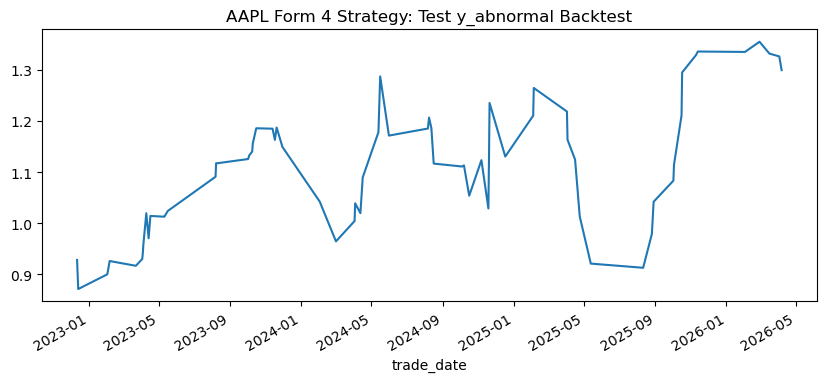

Ticker: META
n_events: 300
Model metrics
n_train: 240
n_test: 60
target: y_abnormal
train_r2: 0.07132927195735927
test_r2: -0.19136294817637944
train_mae: 0.056967147406348256
test_mae: 0.06152129718466133
best_iteration: 120

Backtest metrics
realized_col: y_abnormal
date_col: trade_date
n_days: 60.0000
mean_daily_ret: -0.0261
annualized_return_approx: -6.5655
annualized_vol: 1.1517
sharpe: -5.7005
max_drawdown: -0.8588
win_rate: 0.4000


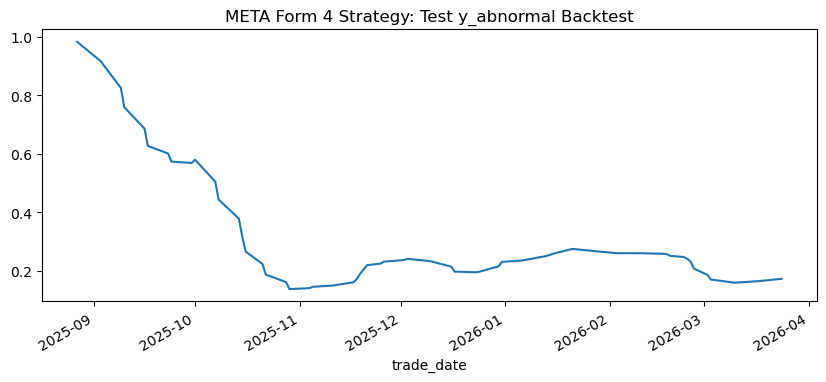

Ticker: GOOGL
n_events: 320
Model metrics
n_train: 256
n_test: 64
target: y_abnormal
train_r2: 0.015143310719973324
test_r2: -0.32785304445004515
train_mae: 0.05395655871339296
test_mae: 0.0796259892996557
best_iteration: 15

Backtest metrics
realized_col: y_abnormal
date_col: trade_date
n_days: 64.0000
mean_daily_ret: 0.0584
annualized_return_approx: 14.7129
annualized_vol: 1.3664
sharpe: 10.7679
max_drawdown: -0.4559
win_rate: 0.7031


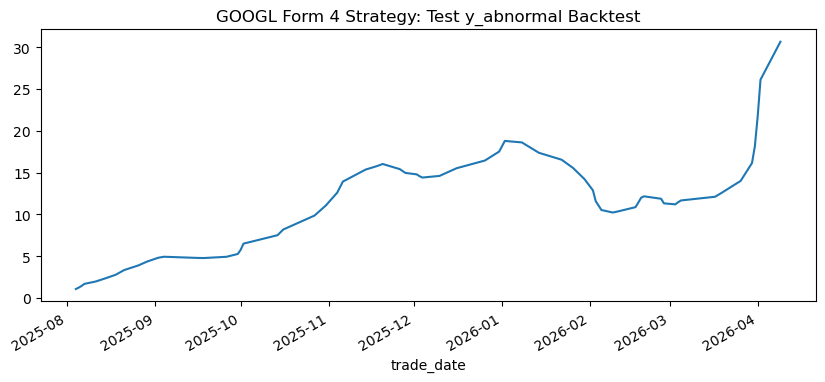

Ticker: AMZN
n_events: 351
Model metrics
n_train: 280
n_test: 71
target: y_abnormal
train_r2: 0.015800268402705764
test_r2: -0.019042168348344823
train_mae: 0.04604796689273875
test_mae: 0.04704754729268042
best_iteration: 15

Backtest metrics
realized_col: y_abnormal
date_col: trade_date
n_days: 70.0000
mean_daily_ret: -0.0043
annualized_return_approx: -1.0719
annualized_vol: 0.9090
sharpe: -1.1792
max_drawdown: -0.5081
win_rate: 0.4571


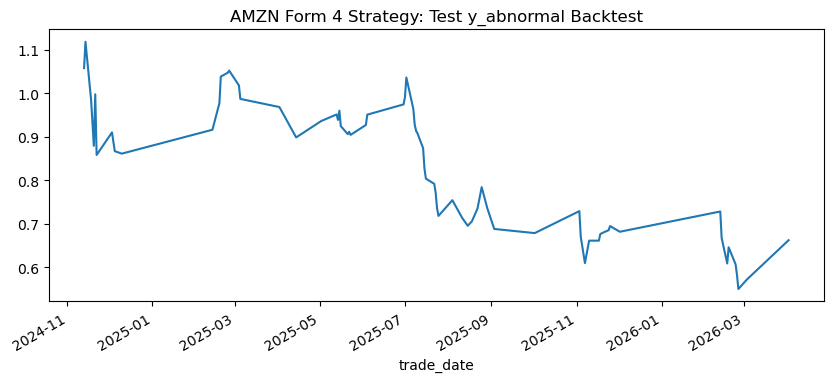

,ticker,n_train,n_test,target,train_r2,test_r2,train_mae,test_mae,best_iteration,bt_realized_col,bt_date_col,bt_n_days,bt_mean_daily_ret,bt_annualized_return_approx,bt_annualized_vol,bt_sharpe,bt_max_drawdown,bt_win_rate
0,AAPL,274,69,y_abnormal,0.064540,-0.051966,0.042995,0.038801,120,y_abnormal,trade_date,69,0.005054,1.273625,0.796673,1.598680,-0.291123,0.550725
1,META,240,60,y_abnormal,0.071329,-0.191363,0.056967,0.061521,120,y_abnormal,trade_date,60,-0.026054,-6.565506,1.151740,-5.700511,-0.858802,0.400000
2,GOOGL,256,64,y_abnormal,0.015143,-0.327853,0.053957,0.079626,15,y_abnormal,trade_date,64,0.058384,14.712864,1.366359,10.767929,-0.455902,0.703125
3,AMZN,280,71,y_abnormal,0.015800,-0.019042,0.046048,0.047048,15,y_abnormal,trade_date,70,-0.004253,-1.071863,0.908980,-1.179193,-0.508111,0.457143


In [ ]:
# target_tickers = ["AAPL", "META", "GOOGL", "AMZN"]

# ticker_results = {}
# summary_rows = []

# for ticker in target_tickers:
#     result = train_and_backtest_one_ticker(
#         events=events,
#         ticker=ticker,
#         feature_cols=feature_cols,
#         target_col="y_abnormal",
#         test_size=0.2,
#         threshold=0.0,
#     )

#     if result is None:
#         continue

#     ticker_results[ticker] = result

#     row = {"ticker": ticker}
#     row.update(result["model_metrics"])
#     row.update({f"bt_{k}": v for k, v in result["test_bt_metrics"].items()})
#     summary_rows.append(row)

# ticker_summary = pd.DataFrame(summary_rows)
# ticker_summary

In [153]:
# feature_df = events[
#     ["ticker", "event_date", "price_t", "future_price", "raw_y", "benchmark_return", "y_abnormal"]
#     + feature_cols
# ].copy()

# print("Feature dataframe shape:", feature_df.shape)
# print("Number of features:", len(feature_cols))

# feature_df.head(20)

In [152]:
# # AAPL rows from common_all, sorted by transaction_date ascending
# aapl_common = common_all[
#     common_all["ticker"].astype(str).str.upper() == "AAPL"
# ].copy()

# aapl_common["transaction_date"] = pd.to_datetime(
#     aapl_common["transaction_date"],
#     errors="coerce"
# )

# aapl_common_asc = aapl_common.sort_values(
#     "transaction_date",
#     ascending=True
# ).reset_index(drop=True)

# print("AAPL common Form 4 rows:", aapl_common_asc.shape)
# print("Date range:", aapl_common_asc["transaction_date"].min(), "to", aapl_common_asc["transaction_date"].max())

# aapl_common_asc.head(30)

In [145]:
cols_to_show = [
    "ticker",
    "n_train", "n_test",
    "target",
    "train_r2", "test_r2",
    "train_mae", "test_mae",
    "best_iteration",
    "bt_n_days",
    "bt_mean_daily_ret",
    "bt_annualized_return_approx",
    "bt_annualized_vol",
    "bt_sharpe",
    "bt_max_drawdown",
    "bt_win_rate",
]

ticker_summary[[c for c in cols_to_show if c in ticker_summary.columns]]

,ticker,n_train,n_test,target,train_r2,test_r2,train_mae,test_mae,best_iteration,bt_n_days,bt_mean_daily_ret,bt_annualized_return_approx,bt_annualized_vol,bt_sharpe,bt_max_drawdown,bt_win_rate
0,AAPL,274,69,y_abnormal,0.064540,-0.051966,0.042995,0.038801,120,69,0.005054,1.273625,0.796673,1.598680,-0.291123,0.550725
1,META,240,60,y_abnormal,0.071329,-0.191363,0.056967,0.061521,120,60,-0.026054,-6.565506,1.151740,-5.700511,-0.858802,0.400000
2,GOOGL,256,64,y_abnormal,0.015143,-0.327853,0.053957,0.079626,15,64,0.058384,14.712864,1.366359,10.767929,-0.455902,0.703125
3,AMZN,280,71,y_abnormal,0.015800,-0.019042,0.046048,0.047048,15,70,-0.004253,-1.071863,0.908980,-1.179193,-0.508111,0.457143


In [146]:
# Build dataset and features
# y = ticker-normalized abnormal forward return; y_abnormal = raw abnormal forward return.
events = build_event_dataset(
    form4_df=common_all,
    price_df=price,
    benchmark_df=spx,
    horizon=20,
    min_periods_norm=20
)
events, feature_cols = build_features(events)

events = aggregate_features_by_ticker_date(events, feature_cols)

events = _add_activity_features(events)

print("Events:", events.shape)
print("Number of features:", len(feature_cols))
print(events[["ticker", "event_date", "price_t", "future_price", "raw_y", "benchmark_return", "y_abnormal", "y", "event_count_60d"]].head())

Events: (1314, 69)
Number of features: 55
  ticker event_date    price_t  future_price     raw_y  benchmark_return  \
0   AAPL 2015-04-23  28.968874     29.594500  0.021596          0.006331   
1   AAPL 2015-04-30  28.673132     29.147928  0.016559          0.004034   
2   AAPL 2015-05-01  28.617544     29.018425  0.014008          0.000189   
3   AAPL 2015-05-04  27.972708     29.054150  0.038661          0.014456   
4   AAPL 2015-05-05  27.797049     28.884453  0.039119          0.010046   

   y_abnormal         y  event_count_60d  
0    0.015266  0.015266                0  
1    0.012525  0.012525                1  
2    0.013819  0.013819                2  
3    0.024204  0.024204                3  
4    0.029073  0.029073                4  


In [147]:
# Train on normalized abnormal return.
model, model_metrics, split_data = train_model(events, feature_cols, target_col="y", test_size=0.2)

Model metrics
n_train: 1051
n_test: 263
target: y
train_r2: 0.13888313635170157
test_r2: -0.042769913963331074
train_mae: 0.0466709969883399
test_mae: 0.05762139232427017
best_iteration: 74


/var/folders/l6/qn_dxw8j00x3g2ft_6s4sz4w0000gn/T/ipykernel_30998/3585003723.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = out.groupby("event_date", group_keys=False).apply(_daily_weights)


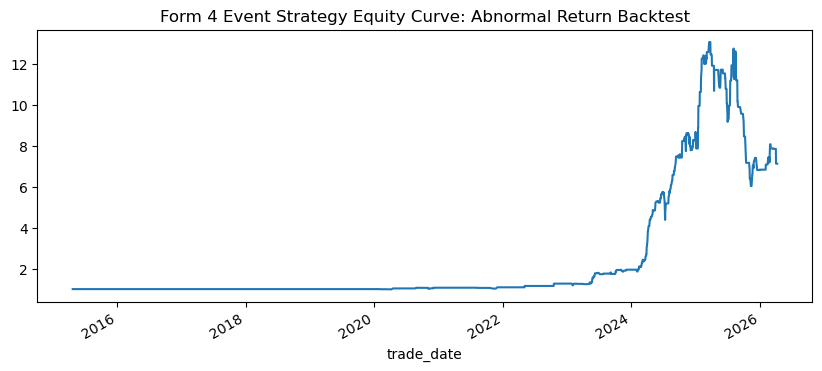

Backtest metrics
realized_col: y_abnormal
date_col: trade_date
n_days: 1001.0000
mean_daily_ret: 0.0022
annualized_return_approx: 0.5535
annualized_vol: 0.3432
sharpe: 1.6130
max_drawdown: -0.5384
win_rate: 0.1429


In [148]:
# Generate positions and backtest on abnormal return.
events_with_pos = generate_positions(events, model, feature_cols, min_events_per_day=2)
equity, daily_ret, bt_metrics = backtest_event_strategy(events_with_pos, realized_col="y_abnormal")

equity.plot(title="Form 4 Event Strategy Equity Curve: Abnormal Return Backtest", figsize=(10, 4))
plt.show()

print("Backtest metrics")
for k, v in bt_metrics.items():
    print(f"{k}: {float(v):.4f}" if isinstance(v, (int, float, np.floating)) else f"{k}: {v}")

/var/folders/l6/qn_dxw8j00x3g2ft_6s4sz4w0000gn/T/ipykernel_30998/3585003723.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = out.groupby("event_date", group_keys=False).apply(_daily_weights)


Test start date: 2025-04-28 00:00:00
Test events: (263, 69)


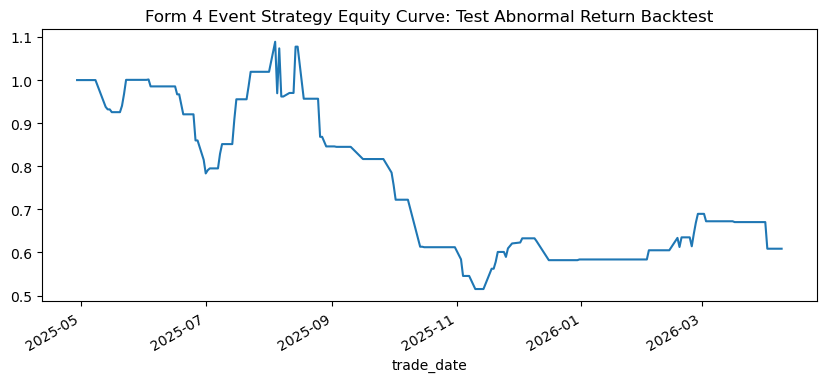

Test backtest metrics
realized_col: y_abnormal
date_col: trade_date
n_days: 177.0000
mean_daily_ret: -0.0023
annualized_return_approx: -0.5770
annualized_vol: 0.5020
sharpe: -1.1495
max_drawdown: -0.5268
win_rate: 0.1751


In [149]:
# Backtest only on test period
# Use the same time split as the model evaluation.

events_sorted = events.sort_values("event_date").copy()

# Same split logic: last 20% as test set
test_frac = 0.2
split_idx = int(len(events_sorted) * (1 - test_frac))

test_start_date = events_sorted.iloc[split_idx]["event_date"]

test_events = events_sorted[events_sorted["event_date"] >= test_start_date].copy()

print("Test start date:", test_start_date)
print("Test events:", test_events.shape)

test_events_with_pos = generate_positions(
    test_events,
    model,
    feature_cols,
    min_events_per_day=2
)

test_equity, test_daily_ret, test_bt_metrics = backtest_event_strategy(
    test_events_with_pos,
    realized_col="y_abnormal"
)

test_equity.plot(
    title="Form 4 Event Strategy Equity Curve: Test Abnormal Return Backtest",
    figsize=(10, 4)
)
plt.show()

print("Test backtest metrics")
for k, v in test_bt_metrics.items():
    print(f"{k}: {float(v):.4f}" if isinstance(v, (int, float, np.floating)) else f"{k}: {v}")

In [150]:
# Optional: permutation importance on the held-out set.
# This helps show which engineered features are useful for the HistGradientBoostingRegressor.
X_train, X_test, y_train, y_test, train_meta, test_meta = split_data

if len(X_test) > 20:
    perm = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=10,
        random_state=42,
        scoring="neg_mean_absolute_error",
    )
    importance = (
        pd.DataFrame({"feature": feature_cols, "importance": perm.importances_mean})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    display(importance.head(20))
else:
    print("Not enough test observations for stable permutation importance.")

,feature,importance
0,signed_shares,0.000441
1,event_count_60d,0.000433
2,ownership_after_log,0.000278
3,signed_dollar_value,0.000275
4,event_count_20d,0.000142
5,relative_trade_size,0.000111
6,weighted_signed_dollar_value,0.000106
7,signed_log_dollar_value,0.000088
8,net_sell_dollar,0.000054
9,tx_price_gt_close,0.000049


In [151]:
# Quick diagnostics: check whether active tickers dominate the sample.
activity_summary = (
    events.groupby("ticker")
    .agg(
        n_events=("ticker", "size"),
        avg_60d_activity=("event_count_60d", "mean"),
        mean_abnormal_return=("y_abnormal", "mean"),
        std_abnormal_return=("y_abnormal", "std"),
    )
    .sort_values("n_events", ascending=False)
)

display(activity_summary)

,n_events,avg_60d_activity,mean_abnormal_return,std_abnormal_return
ticker,,,,
AMZN,351,9.185185,0.000555,0.063380
AAPL,343,6.720117,0.007819,0.054273
GOOGL,320,15.425000,0.018059,0.074529
META,300,24.716667,0.000466,0.073087
